# Compulsory Assignment #3 - Solution Template

## 0. Imports and configuration
We use one shared preprocessing pipeline across the whole notebook.  
The same train / validation / test split is reused in every section.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

## 1.1 Data Preparation
Assignment requirements:
- load the CIFAR-100 train and test splits
- create a 90/10 validation split from the training set
- compute per-channel mean and standard deviation using the training set only
- normalize train, validation, and test images using those statistics
- flatten each image to a 3072-dimensional vector

In [2]:
# Load CIFAR-100 
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar100.load_data(label_mode="fine")

# Convert labels from shape (n, 1) to shape (n,)
y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

# Convert images to float32 for downstream processing
X_train_full = X_train_full.astype("float32")
X_test = X_test.astype("float32")

print("Full training set:", X_train_full.shape, y_train_full.shape)
print("Test set:", X_test.shape, y_test.shape)

Full training set: (50000, 32, 32, 3) (50000,)
Test set: (10000, 32, 32, 3) (10000,)


In [3]:
# Create validation split from the original training set 
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full # maintain class distribution in splits
)

print("Training split:", X_train.shape, y_train.shape)
print("Validation split:", X_val.shape, y_val.shape)
print("Test split:", X_test.shape, y_test.shape)

Training split: (45000, 32, 32, 3) (45000,)
Validation split: (5000, 32, 32, 3) (5000,)
Test split: (10000, 32, 32, 3) (10000,)


In [4]:
# Compute per-channel mean and std using the training split only
channel_mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
channel_std = X_train.std(axis=(0, 1, 2), keepdims=True) 

print("Per-channel mean:", channel_mean.reshape(-1))
print("Per-channel std:", channel_std.reshape(-1))

Per-channel mean: [129.29881  124.03771  112.348564]
Per-channel std: [68.1466  65.36531 70.38802]


In [5]:
# Normalize all splits using training-set statistics only
X_train_norm = (X_train - channel_mean) / channel_std
X_val_norm = (X_val - channel_mean) / channel_std
X_test_norm = (X_test - channel_mean) / channel_std

# Flatten normalized images for pixel-based classification
X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_val_flat = X_val_norm.reshape(len(X_val_norm), -1)
X_test_flat = X_test_norm.reshape(len(X_test_norm), -1)

print("Normalized training images:", X_train_norm.shape)
print("Flattened training features:", X_train_flat.shape)

Normalized training images: (45000, 32, 32, 3)
Flattened training features: (45000, 3072)


## 1.2 Autoencoder-Based Feature Learning
We build a convolutional autoencoder with:
- an encoder containing at least two convolutional blocks
- a symmetric decoder
- reconstruction loss (MSE)

The encoder output is used as the latent feature representation for Part 1.3.

In [6]:
def build_autoencoder(input_shape=(32, 32, 3)):
    # Encoder
    encoder_input = keras.Input(shape=input_shape, name="encoder_input")

    x = layers.Conv2D(32, kernel_size=3, padding="same", activation="relu")(encoder_input)
    x = layers.MaxPooling2D(pool_size=2, padding="same")(x)   

    x = layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2, padding="same")(x)   

    x = layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")(x)
    latent = layers.MaxPooling2D(pool_size=2, padding="same", name="latent_space")(x)  

    encoder = keras.Model(encoder_input, latent, name="encoder")

    # Decoder
    decoder_input = keras.Input(shape=encoder.output_shape[1:], name="decoder_input")

    x = layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")(decoder_input)
    x = layers.UpSampling2D(size=2)(x)  

    x = layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(size=2)(x)  

    x = layers.Conv2D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(size=2)(x)  

    decoder_output = layers.Conv2D(3, kernel_size=3, padding="same", activation="linear")(x)
    decoder = keras.Model(decoder_input, decoder_output, name="decoder")

    autoencoder_input = encoder_input
    autoencoder_output = decoder(encoder(autoencoder_input))
    autoencoder = keras.Model(autoencoder_input, autoencoder_output, name="conv_autoencoder")

    return encoder, decoder, autoencoder



In [7]:
encoder, decoder, autoencoder = build_autoencoder()
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")

encoder.summary()
decoder.summary()
autoencoder.summary()

2026-04-10 16:33:38.096626: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-10 16:33:38.096799: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-10 16:33:38.096814: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-10 16:33:38.097215: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-10 16:33:38.097856: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         7385

In [8]:
autoencoder_history = autoencoder.fit(
    X_train_norm,
    X_train_norm,
    validation_data=(X_val_norm, X_val_norm),
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5


2026-04-10 16:33:41.751832: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-10 16:33:41.795764: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


352/352 [==============================] - 19s 49ms/step - loss: 0.2286 - val_loss: 0.1416
Epoch 2/5
352/352 [==============================] - 17s 50ms/step - loss: 0.1306 - val_loss: 0.1143
Epoch 3/5
352/352 [==============================] - 17s 50ms/step - loss: 0.1108 - val_loss: 0.1010
Epoch 4/5
352/352 [==============================] - 18s 50ms/step - loss: 0.0973 - val_loss: 0.0899
Epoch 5/5
352/352 [==============================] - 17s 48ms/step - loss: 0.0894 - val_loss: 0.0872


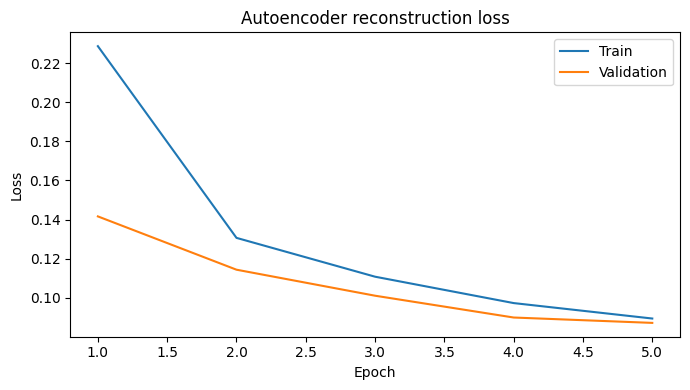

In [9]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(history_df.index + 1, history_df["loss"], label="Train")
    plt.plot(history_df.index + 1, history_df["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(autoencoder_history, "Autoencoder reconstruction loss")

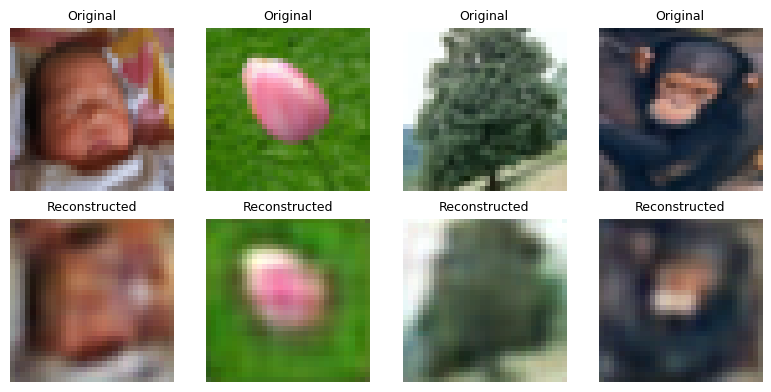

In [10]:
# ADDITIONAL STEP: Visualize some reconstructions from the validation set

def show_reconstructions(model, images, n=8):
    sample = images[:n]
    reconstructed = model.predict(sample, verbose=0)

    # Convert normalized images back to display range
    sample_display = np.clip(sample * channel_std + channel_mean, 0, 255).astype("uint8")
    recon_display = np.clip(reconstructed * channel_std + channel_mean, 0, 255).astype("uint8")

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))
    for i in range(n):
        axes[0, i].imshow(sample_display[i])
        axes[0, i].axis("off")
        axes[0, i].set_title("Original", fontsize=9)

        axes[1, i].imshow(recon_display[i])
        axes[1, i].axis("off")
        axes[1, i].set_title("Reconstructed", fontsize=9)

    plt.tight_layout()
    plt.show()

show_reconstructions(autoencoder, X_val_norm, n=4)

In [11]:
# Extract latent feature maps and flatten them into vectors
Z_train = encoder.predict(X_train_norm, batch_size=256, verbose=1)
Z_val = encoder.predict(X_val_norm, batch_size=256, verbose=1)
Z_test = encoder.predict(X_test_norm, batch_size=256, verbose=1)

Z_train_flat = Z_train.reshape(len(Z_train), -1)
Z_val_flat = Z_val.reshape(len(Z_val), -1)
Z_test_flat = Z_test.reshape(len(Z_test), -1)

print("Latent train feature shape:", Z_train.shape)
print("Flattened latent train feature shape:", Z_train_flat.shape)

40/40 [==============================] - 0s 6ms/step
Latent train feature shape: (45000, 4, 4, 128)
Flattened latent train feature shape: (45000, 2048)


## 1.3 Classification Using Pixel and Latent Features
To ensure a fair comparison:
- we use the **same classifier type**
- we use the **same hyperparameters**
- we evaluate both models on validation and test data

In [12]:
def fit_and_evaluate_classifier(X_train_features, y_train, X_val_features, y_val, X_test_features, y_test):
    model = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("classifier", RidgeClassifier(alpha=1.0))
    ])

    model.fit(X_train_features, y_train)

    val_pred = model.predict(X_val_features)
    test_pred = model.predict(X_test_features)

    results = {
        "validation_accuracy": accuracy_score(y_val, val_pred),
        "test_accuracy": accuracy_score(y_test, test_pred)
    }
    return model, results

pixel_classifier, pixel_results = fit_and_evaluate_classifier(
    X_train_flat, y_train, X_val_flat, y_val, X_test_flat, y_test
)

latent_classifier, latent_results = fit_and_evaluate_classifier(
    Z_train_flat, y_train, Z_val_flat, y_val, Z_test_flat, y_test
)

/opt/anaconda3/envs/course/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.37389e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/course/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.21943e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [13]:
comparison_df = pd.DataFrame([
    {
        "feature_type": "Flattened pixel features",
        "validation_accuracy": pixel_results["validation_accuracy"],
        "test_accuracy": pixel_results["test_accuracy"]
    },
    {
        "feature_type": "Latent autoencoder features",
        "validation_accuracy": latent_results["validation_accuracy"],
        "test_accuracy": latent_results["test_accuracy"]
    }
])

comparison_df["validation_accuracy"] = comparison_df["validation_accuracy"].round(3)
comparison_df["test_accuracy"] = comparison_df["test_accuracy"].round(3)

comparison_df

,feature_type,validation_accuracy,test_accuracy
0,Flattened pixel features,0.125,0.117
1,Latent autoencoder features,0.297,0.299


## 1.4 CNN Model
We now train a convolutional neural network directly on the normalized images.

The model below should satisfy this requirements:
- at least three Conv2D layers
- two or more convolutional blocks
- ReLU activations
- max pooling after each block
- at least one dense layer before the final classifier
- softmax output over all 100 classes

In [14]:
def build_cnn_classifier(input_shape=(32, 32, 3), n_classes=100):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax")
    ], name="cnn_classifier")

    return model



In [15]:
cnn_model = build_cnn_classifier()

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True, # had some issues, these are fixes, you probably won't need them
    jit_compile=False,
)

cnn_model.summary()
print(f"Trainable parameters: {cnn_model.count_params():,}")

Model: "cnn_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 conv2d_8 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 conv2d_10 (Conv2D)          (None, 16, 16, 64)        36928     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                               

In [16]:
cnn_history = cnn_model.fit(
    X_train_norm,
    y_train,
    validation_data=(X_val_norm, y_val),
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
352/352 [==============================] - 23s 63ms/step - loss: 4.0391 - accuracy: 0.0903 - val_loss: 3.5057 - val_accuracy: 0.1802
Epoch 2/5
352/352 [==============================] - 24s 67ms/step - loss: 3.3305 - accuracy: 0.2002 - val_loss: 2.9801 - val_accuracy: 0.2822
Epoch 3/5
352/352 [==============================] - 22s 64ms/step - loss: 2.9322 - accuracy: 0.2719 - val_loss: 2.7371 - val_accuracy: 0.3198
Epoch 4/5
352/352 [==============================] - 23s 64ms/step - loss: 2.6655 - accuracy: 0.3216 - val_loss: 2.5350 - val_accuracy: 0.3568
Epoch 5/5
352/352 [==============================] - 23s 64ms/step - loss: 2.4460 - accuracy: 0.3659 - val_loss: 2.4177 - val_accuracy: 0.3848


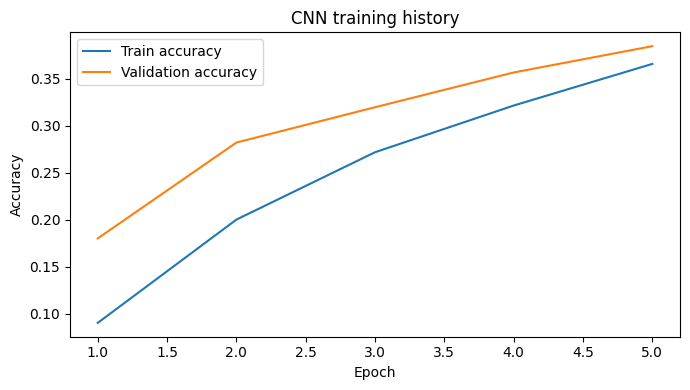

In [17]:
history_df = pd.DataFrame(cnn_history.history)

plt.figure(figsize=(7, 4))
plt.plot(history_df.index + 1, history_df["accuracy"], label="Train accuracy")
plt.plot(history_df.index + 1, history_df["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN training history")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
cnn_val_loss, cnn_val_accuracy = cnn_model.evaluate(X_val_norm, y_val, verbose=0)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_norm, y_test, verbose=0)

print(f"CNN validation accuracy: {cnn_val_accuracy:.4f}")
print(f"CNN test accuracy: {cnn_test_accuracy:.4f}")

CNN validation accuracy: 0.3848
CNN test accuracy: 0.3821


## Final comparison and conclusion
The summary below combines the key results from:
- the linear classifier on flattened pixels
- the linear classifier on latent autoencoder features
- the CNN classifier

In [19]:
final_results = pd.DataFrame([
    {
        "model": "Ridge classifier on flattened pixels",
        "validation_accuracy": pixel_results["validation_accuracy"],
        "test_accuracy": pixel_results["test_accuracy"]
    },
    {
        "model": "Ridge classifier on latent features",
        "validation_accuracy": latent_results["validation_accuracy"],
        "test_accuracy": latent_results["test_accuracy"]
    },
    {
        "model": "CNN classifier",
        "validation_accuracy": cnn_val_accuracy,
        "test_accuracy": cnn_test_accuracy
    }
])

final_results["validation_accuracy"] = final_results["validation_accuracy"].round(4)
final_results["test_accuracy"] = final_results["test_accuracy"].round(4)
final_results.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

,model,validation_accuracy,test_accuracy
0,CNN classifier,0.3848,0.3821
1,Ridge classifier on latent features,0.2970,0.2990
2,Ridge classifier on flattened pixels,0.1248,0.1166


A typical outcome (if every step was done correctly) is:
- the **CNN** performs best
- the **autoencoder**  outperform raw pixels as it learns a compact but informative representation
- the **raw pixel** is useful as a simple benchmark 

this is true in this case and cnn can further improve (only 5 epochs and two blocks)